# PPI++ Confidence Interval Overlap Analysis (Odds Ratio Edition)

This notebook quantifies the overlap and statistical compatibility between:
1. **Our Standard LLM Model's 95% CIs** (computed via bootstrapping on the full $N=5,749$ dataset).
2. **The Human-Corrected PPI++ 95% CIs** (computed using predictions corrected by the $n=100$ human gold validation sample).

**Note:** To match the main text of the paper, all covariates are built using **Patsy sum coding** and the model is fit using **unregularized logistic regression** (matching statsmodels in the paper exactly). All parameters are reported as **Odds Ratios (OR)**.

In [1]:
import pandas as pd
import numpy as np
import re
import patsy
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import sklearn.linear_model as _slm
import warnings
warnings.filterwarnings('ignore')

# Apply scikit-learn patch for ppi_py compatibility with older scikit-learn versions
_orig = _slm.LogisticRegression
class _PatchedLR(_orig):
    def __init__(self, penalty=None, **kw):
        if penalty is None: 
            penalty = 'none'
        super().__init__(penalty=penalty, **kw)
_slm.LogisticRegression = _PatchedLR
import ppi_py
print("Setup completed successfully.")

Setup completed successfully.


In [ ]:
print("Loading data...")
df_post = pd.read_pickle("../data/oon/df_post_oon.pkl")
df_reg = df_post[['emotion__anger', 'emotion__fear', 'emotion__sadness', 'emotion__disgust', 'emotion__surprise']]
df_annot = pd.read_csv('../ablations/sample_emo_annot.csv')

# Preprocessing & Text Normalization
def normalize(t):
    if not isinstance(t, str): return ''
    t_clean = re.sub(r'[^a-zA-Z0-9\s]', '', t.lower())
    return ' '.join(t_clean.split())

df_reg['_norm']   = df_reg['selftext'].apply(normalize)
df_annot['_norm'] = df_annot['selftext'].apply(normalize)

persona_cols = ['persona_0_prob','persona_1_prob','persona_2_prob',
                'persona_3_prob','persona_4_prob','persona_5_prob']
control_raw  = ['age_group','gender','relationship_cat']
llm_emo_cols = ['emotion__anger','emotion__fear','emotion__sadness','emotion__disgust']

merged = df_annot.merge(
    df_reg[['_norm'] + persona_cols + control_raw + llm_emo_cols].drop_duplicates('_norm'),
    on='_norm', how='left'
)

# Extract subsets
gold = merged.dropna(subset=['persona_0_prob'] + control_raw).copy()
df_full = df_reg.dropna(subset=persona_cols + control_raw).copy()

# Add balances to both datasets
def add_balances(df):
    eps = 1e-8
    X = np.clip(df[persona_cols].values, eps, None)
    df['balance_1'] = np.sqrt(1.5) * (1.0/3.0) * np.log((X[:, 0] * X[:, 2] * X[:, 5]) / (X[:, 1] * X[:, 3] * X[:, 4]))
    df['balance_2'] = np.sqrt(2.0/3.0) * np.log(np.sqrt(X[:, 0] * X[:, 5]) / X[:, 2])
    df['balance_3'] = np.sqrt(0.5) * np.log(X[:, 0] / X[:, 5])
    df['balance_4'] = np.sqrt(2.0/3.0) * np.log(np.sqrt(X[:, 1] * X[:, 4]) / X[:, 3])
    df['balance_5'] = np.sqrt(0.5) * np.log(X[:, 1] / X[:, 4])

add_balances(df_full)
add_balances(gold)
print(f"Gold set matched size: {len(gold)} | Full unlabeled size: {len(df_full)}")

Loading data...
Gold set matched size: 100 | Full unlabeled size: 5749


In [3]:
# Formula used in the paper
formula_str = "target_var ~ balance_1 + balance_2 + balance_3 + balance_4 + balance_5 + C(relationship_cat, Sum) + C(age_group, Sum) + C(gender, Sum)"

emo_map = {
    'anger':   ('anger (R)',   'anger (G)',   'emotion__anger'),
    'fear':    ('fear (R)',    'fear (G)',    'emotion__fear'),
    'disgust': ('disgust (R)', 'disgust (G)', 'emotion__disgust'),
}

def get_jaccard_overlap(low1, hi1, low2, hi2):
    intersection = max(0, min(hi1, hi2) - max(low1, low2))
    union = max(hi1, hi2) - min(low1, low2)
    return intersection / union if union > 0 else 0.0

all_results = {}

print(f"{'Emotion':<8} | {'Feature':<18} | {'LLM OR':<10} | {'LLM OR CI 95%':<22} | {'PPI++ OR CI 95%':<22} | {'Jaccard Overlap':<15} | {'LLM inside PPI?':<15}")
print("-" * 120)

for emo, (acol, bcol, full_col) in emo_map.items():
    df_full['target_var'] = df_full[full_col].values.astype(float)
    gold['target_var'] = ((gold[acol].values + gold[bcol].values) >= 1).astype(float)
    
    # Compile design matrices via Patsy (exact same coding as statsmodels in paper)
    y_full_df, X_full_df = patsy.dmatrices(formula_str, df_full, return_type='dataframe')
    y_gold_df, X_gold_df = patsy.build_design_matrices([y_full_df.design_info, X_full_df.design_info], gold, return_type='dataframe')
    
    X_full = X_full_df.values
    X_gold = X_gold_df.values
    
    gold_norms = set(gold['_norm'])
    unlabeled_mask = ~df_full['_norm'].isin(gold_norms)
    X_unlabeled = X_full[unlabeled_mask]
    
    Y_gold_raw = gold['target_var'].values
    Yhat_gold = gold[full_col].values.astype(float)
    Yhat_unlabeled = df_full[unlabeled_mask][full_col].values.astype(float)
    Y_full_llm = df_full['target_var'].values
    
    # A) Fit main LLM model (unregularized: C=1e8, fit_intercept=False)
    m_full = _slm.LogisticRegression(C=1e8, fit_intercept=False, max_iter=1000, solver='lbfgs')
    m_full.fit(X_full, Y_full_llm)
    llm_coefs = m_full.coef_[0]
    
    # Bootstrap on LLM model to get LLM CI bounds
    boot_coefs = []
    rng = np.random.default_rng(42)
    n_f = len(X_full)
    for _ in range(200):
        idx = rng.integers(0, n_f, size=n_f)
        m = _slm.LogisticRegression(C=1e8, fit_intercept=False, max_iter=1000, solver='lbfgs')
        m.fit(X_full[idx], Y_full_llm[idx])
        boot_coefs.append(m.coef_[0])
    boot_coefs = np.array(boot_coefs)
    llm_lo = np.percentile(boot_coefs, 2.5, axis=0)
    llm_hi = np.percentile(boot_coefs, 97.5, axis=0)
    
    # C) Run PPI++ Interval Correction
    ppi_lo, ppi_hi = ppi_py.ppi_logistic_ci(
        X_gold, Y_gold_raw, Yhat_gold,
        X_unlabeled, Yhat_unlabeled,
        alpha=0.05, lam=None
    )
    
    # Exponentiate outputs for Odds Ratio (OR)
    all_results[emo] = {
        'features': X_full_df.columns,
        'llm_or': np.exp(llm_coefs), 
        'llm_or_lo': np.exp(llm_lo), 
        'llm_or_hi': np.exp(llm_hi),
        'ppi_or_lo': np.exp(ppi_lo), 
        'ppi_or_hi': np.exp(ppi_hi),
        'llm_lo_raw': llm_lo,
        'llm_hi_raw': llm_hi,
        'ppi_lo_raw': ppi_lo,
        'ppi_hi_raw': ppi_hi
    }
    
    for i, fname in enumerate(X_full_df.columns):
        if 'balance' not in fname and 'Intercept' not in fname:
            continue
            
        display_name = fname
        if 'Intercept' in fname:
            display_name = 'Intercept'
        elif 'balance_' in fname:
            num = fname.split('_')[-1]
            display_name = f"Balance {num} (ILR)"
            
        lor = np.exp(llm_coefs[i])
        llo, lhi = np.exp(llm_lo[i]), np.exp(llm_hi[i])
        plo, phi = np.exp(ppi_lo[i]), np.exp(ppi_hi[i])
        
        # Jaccard index can be calculated directly in parameter (log-odds) space
        jaccard = get_jaccard_overlap(llm_lo[i], llm_hi[i], ppi_lo[i], ppi_hi[i])
        inside = plo <= lor <= phi
        
        inside_str = "YES" if inside else "NO"
        print(f"{emo:<8} | {display_name:<18} | {lor:>10.3f} | [{llo:>5.3f}, {lhi:>5.3f}] | [{plo:>6.3f}, {phi:>6.3f}] | {jaccard:>15.1%} | {inside_str:>15}")
    print("-" * 120)

Emotion  | Feature            | LLM OR     | LLM OR CI 95%          | PPI++ OR CI 95%        | Jaccard Overlap | LLM inside PPI?
------------------------------------------------------------------------------------------------------------------------
anger    | Intercept          |      2.305 | [2.101, 2.568] | [ 0.802,  2.499] |           14.9% |             YES
anger    | Balance 1 (ILR)    |      0.927 | [0.881, 0.968] | [ 0.628,  1.168] |           15.3% |             YES
anger    | Balance 2 (ILR)    |      1.036 | [0.981, 1.101] | [ 0.910,  1.671] |           18.9% |             YES
anger    | Balance 3 (ILR)    |      1.024 | [0.979, 1.067] | [ 0.736,  1.281] |           15.4% |             YES
anger    | Balance 4 (ILR)    |      1.080 | [1.020, 1.137] | [ 0.818,  1.535] |           17.2% |             YES
anger    | Balance 5 (ILR)    |      0.999 | [0.952, 1.052] | [ 0.793,  1.468] |           16.3% |             YES
------------------------------------------------------------

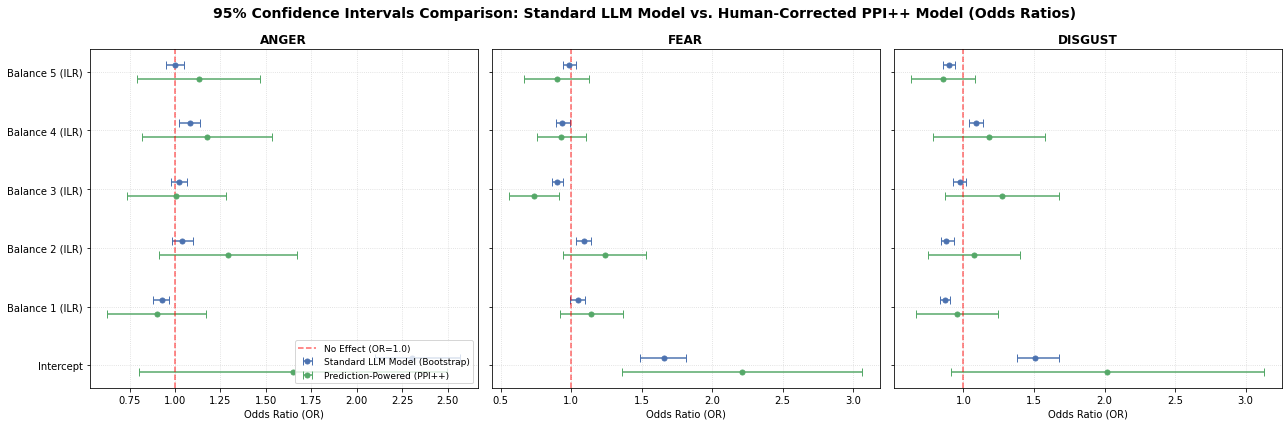

Visual forest plot generated and saved to 'ablations/ppi_overlap_forest_plot_or.png'.


In [4]:
# Plot Forest plots for visual verification (in Odds Ratios)
emotions = list(emo_map.keys())
fig, axes = plt.subplots(1, len(emotions), figsize=(18, 6), sharey=True)
fig.suptitle("95% Confidence Intervals Comparison: Standard LLM Model vs. Human-Corrected PPI++ Model (Odds Ratios)", 
             fontsize=14, fontweight='bold', y=0.98)

for ax, emo in zip(axes, emotions):
    r = all_results[emo]
    cols = list(r['features'])
    
    # Extract indices of Intercept and Balances
    indices = [cols.index(c) for c in cols if 'balance' in c or 'Intercept' in c]
    plot_names = ['Intercept'] + [f"Balance {c.split('_')[-1]} (ILR)" for c in cols if 'balance' in c]
    y_pos = np.arange(len(indices))
    
    # Standard LLM model CI (using bootstrapping)
    ax.errorbar(r['llm_or'][indices], y_pos + 0.12, 
                xerr=[r['llm_or'][indices] - r['llm_or_lo'][indices], r['llm_or_hi'][indices] - r['llm_or'][indices]],
                fmt='o', color='#4C72B0', label='Standard LLM Model (Bootstrap)', capsize=4, markersize=5)
    
    # Human-corrected PPI++ model CI
    ppi_mid = (r['ppi_or_lo'][indices] + r['ppi_or_hi'][indices]) / 2.0
    ax.errorbar(ppi_mid, y_pos - 0.12,
                xerr=[ppi_mid - r['ppi_or_lo'][indices], r['ppi_or_hi'][indices] - ppi_mid],
                fmt='o', color='#55A868', label='Prediction-Powered (PPI++)', capsize=4, markersize=5)
    
    ax.set_title(emo.upper(), fontsize=12, fontweight='bold')
    ax.axvline(1.0, color='red', linestyle='--', alpha=0.6, label='No Effect (OR=1.0)')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_names, fontsize=10)
    ax.set_xlabel("Odds Ratio (OR)", fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.5)

axes[0].legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('ppi_overlap_forest_plot_or.png', dpi=150)
plt.show()
print("Visual forest plot generated and saved to 'ablations/ppi_overlap_forest_plot_or.png'.")